## TASK : Classification of natural disaster Tweets

## Imports

In [1]:
# Imports all libraries that we need
import matplotlib.pyplot as plt
plt.style.use('ggplot') # to change the style
import numpy as np
import os
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
from sklearn.model_selection import train_test_split

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Notebook Explanation

### Section 1 - Data Exploration
In this section we load the data from the CSV files and check the size of each set.
We also create visualizations to better understand the dataset, including:
- Number of words per tweet
- Number of unique words per tweet
- Average word length per tweet
- Number of characters per tweet
- Length of the last word per tweet
- Number of URLs per tweet
- Average number of characters per word
- Number of punctuation marks per tweet
- Number of hashtags per tweet
- Number of @mentions per tweet
- Number of stop words per tweet

Each visualization compares disaster tweets vs non-disaster tweets to find patterns.

### Section 2 - Text Cleaning
First we create visualization functions to understand the most frequent stop words,
URLs, mentions, and bigrams in the dataset.

Then we apply three cleaning configurations to prepare the text for the model:

- **Config 1:** Lowercase, remove URLs, remove mentions, remove punctuation
- **Config 2:** Config 1 + remove stop words
- **Config 3:** Config 1 + apply stemming (reduce words to their root form)

### Section 3 - Neural Network Implementation
**Vectorization:**
We test two types of vectorization using TF-IDF:
- **TV1:** Uses the full vocabulary from the dataset
- **TV2:** Uses only the top 5000 most frequent words and bigrams

**Model Architecture:**
All models share the same structure regardless of vectorization:
- Input layer
- Dense layer: 256 neurons, ReLU activation
- Dense layer: 128 neurons, ReLU activation
- Dense layer: 64 neurons, ReLU activation
- Output layer: 1 neuron, Sigmoid activation (binary classification)

We use ReLU to avoid the vanishing gradient problem, and Sigmoid because this is a binary classification problem (disaster or not).
We also use Dropout (0.3) after each hidden layer, which randomly turns off 30% of neurons during training to prevent overfitting.

**Model Compile:**
We compile each model using:
- Loss function: `binary_crossentropy` (standard for binary problems)
- Metrics: Accuracy and Precision

**Fit and Metrics:**
We train each model and save the weights to reuse them later without retraining.
After training we calculate Accuracy, F1-score and Confusion Matrix for each model.

### Section 4 - Results Comparison
Here we plot all model results in a single bar chart to easily compare
Accuracy and F1-score across all configurations and vectorizations.

### Section 5 - Cleaning Analysis
Here we answer the questions from Section 2 about the impact of each cleaning technique,
and present a comparative table with all results.

### Section 6 - Real-Time Prediction
Here we reload the best model from each vectorization using the saved weights,
without needing to retrain. We also save the vectorizer to a file so we don't need
to redefine it again.

For **TV1** the best model was **Config 3** (Accuracy: 0.7571, F1: 0.6997).
For **TV2** the best model was **Config 1** (Accuracy: 0.7735, F1: 0.7298).

The user can type any tweet and the function will automatically clean the text,
vectorize it, and show the prediction and confidence score for both models.

# 1. Exploration and Visualizarion of Dataset

In [2]:
# Load the data
import pandas as pd

X_train = pd.read_csv('/content/train.csv')
X_test = pd.read_csv('/content/test.csv')

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    X_train['target'],
    test_size=0.2,
    random_state=42)

In [3]:
# Size of each set
print("Size of the training data set: ", len(X_train))
print("Size of the validation data set: ", len(X_val))

# Tweets of each type found in the training dataset
print("")
X_train['target'].value_counts()

Size of the training data set:  6090
Size of the validation data set:  1523



,count
target,
0,3468
1,2622


## Visualization of the data set

### Number of words per Tweet

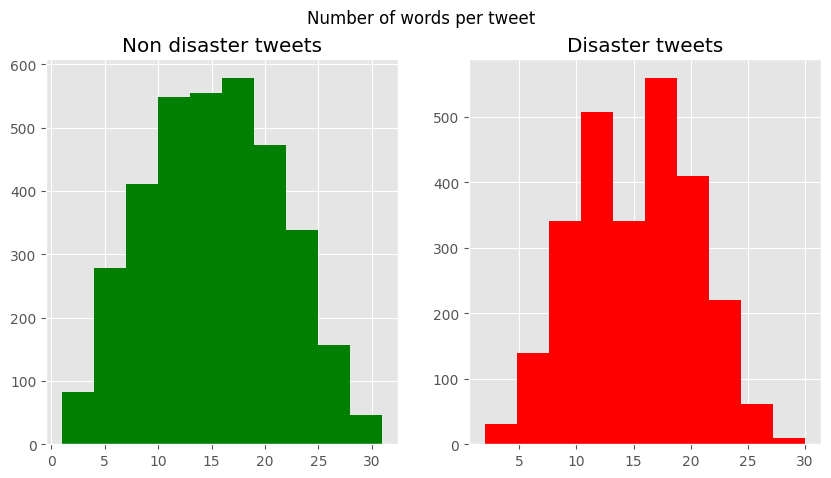

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

# We calculate the number of words
tweet_len_0 = X_train[X_train['target'] == 0]['text'].str.split().map(lambda x: len(x))
tweet_len_1 = X_train[X_train['target'] == 1]['text'].str.split().map(lambda x: len(x))

ax1.hist(tweet_len_0, color='green')
ax1.set_title('Non disaster tweets')

ax2.hist(tweet_len_1, color='red')
ax2.set_title('Disaster tweets')

fig.suptitle('Number of words per tweet')

plt.show()

### Number of unique words per Tweet

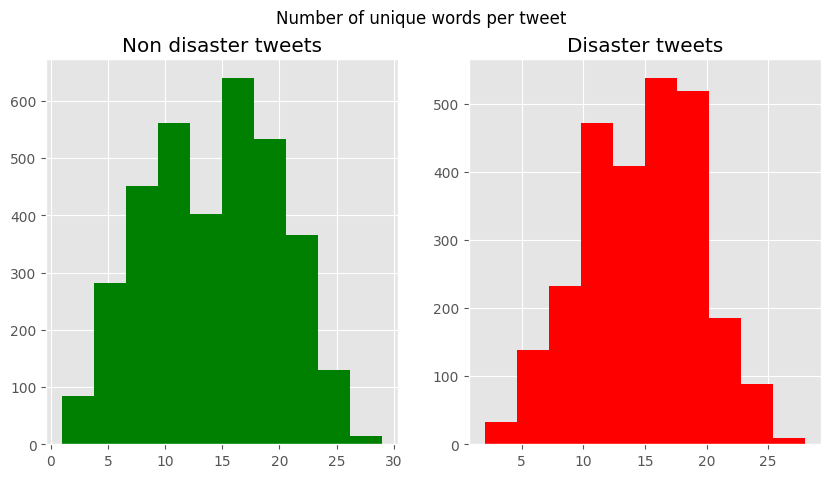

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

# We calculate the number of unique words
tweet_len_0 = X_train[X_train['target'] == 0]['text'].str.split().map(lambda x: len(set(x)))
tweet_len_1 = X_train[X_train['target'] == 1]['text'].str.split().map(lambda x: len(set(x)))

ax1.hist(tweet_len_0, color='green')
ax1.set_title('Non disaster tweets')

ax2.hist(tweet_len_1, color='red')
ax2.set_title('Disaster tweets')

fig.suptitle('Number of unique words per tweet')

plt.show()

### Average word length per Tweet

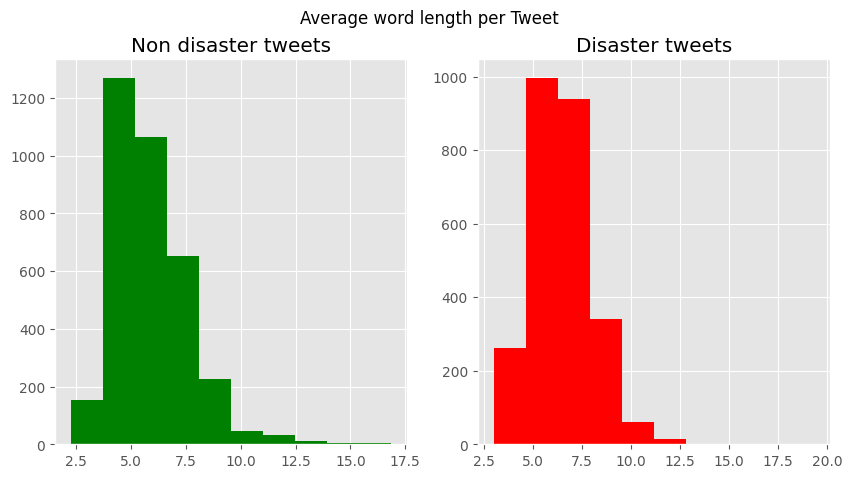

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

# We calculate the number of words
tweet_len_0 = X_train[X_train['target'] == 0]['text'].str.split().map(lambda x: np.mean([len(i) for i in x]))
tweet_len_1 = X_train[X_train['target'] == 1]['text'].str.split().map(lambda x: np.mean([len(i) for i in x]))

ax1.hist(tweet_len_0, color='green')
ax1.set_title('Non disaster tweets')

ax2.hist(tweet_len_1, color='red')
ax2.set_title('Disaster tweets')

fig.suptitle('Average word length per Tweet')

plt.show()

### Number of characters per tweet

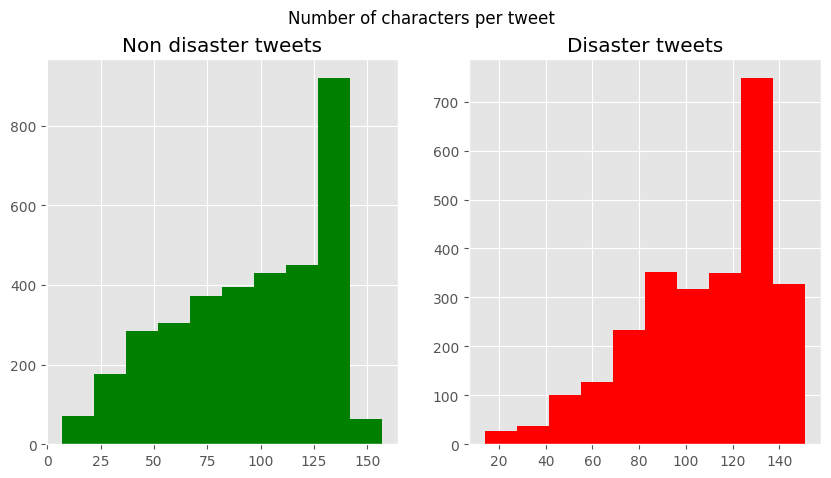

In [7]:
# Measure the total lengh of the tweet
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

# Calculamos el número de caracteres por tweet
tweet_len_0 = X_train[X_train['target'] == 0]['text'].str.len()
tweet_len_1 = X_train[X_train['target'] == 1]['text'].str.len()

ax1.hist(tweet_len_0, color='green')
ax1.set_title('Non disaster tweets')

ax2.hist(tweet_len_1, color='red')
ax2.set_title('Disaster tweets')

fig.suptitle('Number of characters per tweet')

plt.show()

### Number of end words per Tweet

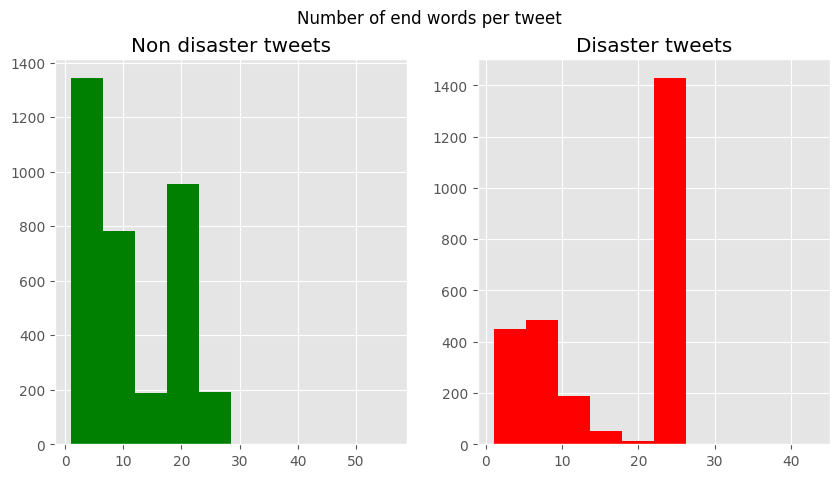

In [8]:
# Measure the lenght of the end word, becuase the disaster tweets can terminates in explosion, destroyed, etc.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

tweet_len_0 = X_train[X_train['target'] == 0]['text'].str.split().map(lambda x: len(x[-1]) if len(x) > 0 else 0)
tweet_len_1 = X_train[X_train['target'] == 1]['text'].str.split().map(lambda x: len(x[-1]) if len(x) > 0 else 0)

ax1.hist(tweet_len_0, color='green')
ax1.set_title('Non disaster tweets')

ax2.hist(tweet_len_1, color='red')
ax2.set_title('Disaster tweets')

fig.suptitle('Number of end words per tweet')

plt.show()

### Number of urls per Tweet

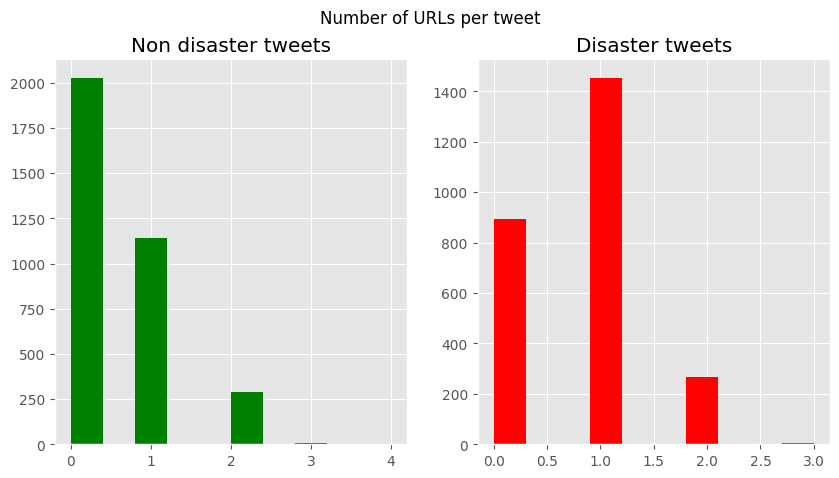

In [9]:
# Counts how many links exist in each tweet; real notices can contain links.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

tweet_len_0 = X_train[X_train['target'] == 0]['text'].str.split().map(lambda x: len([w for w in x if w.startswith('http')]))
tweet_len_1 = X_train[X_train['target'] == 1]['text'].str.split().map(lambda x: len([w for w in x if w.startswith('http')]))

ax1.hist(tweet_len_0, color='green')
ax1.set_title('Non disaster tweets')

ax2.hist(tweet_len_1, color='red')
ax2.set_title('Disaster tweets')

fig.suptitle('Number of URLs per tweet')

plt.show()

### Average number of characters per Tweet

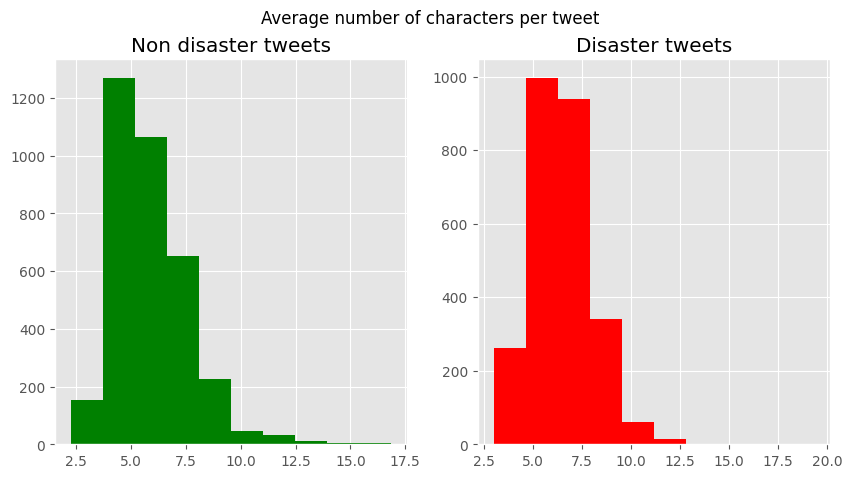

In [32]:
# Calculates the average number of characters per word; for example, in “disaster,” it uses large words like “evacuation.”
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

tweet_len_0 = X_train[X_train['target'] == 0]['text'].str.split().map(lambda x: sum(len(w) for w in x) / len(x) if len(x) > 0 else 0)
tweet_len_1 = X_train[X_train['target'] == 1]['text'].str.split().map(lambda x: sum(len(w) for w in x) / len(x) if len(x) > 0 else 0)

ax1.hist(tweet_len_0, color='green')
ax1.set_title('Non disaster tweets')

ax2.hist(tweet_len_1, color='red')
ax2.set_title('Disaster tweets')

fig.suptitle('Average number of characters per tweet')

plt.show()

### Number of punctuation marks per Tweet

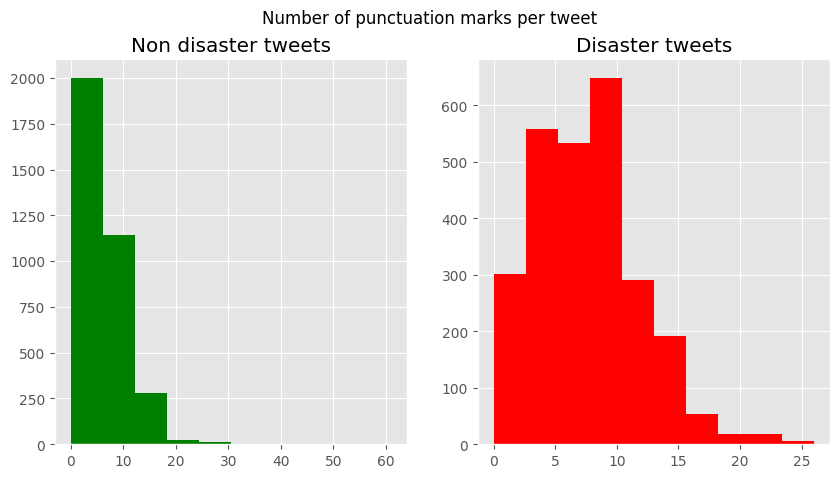

In [11]:
# Counts punctuation marks, non-disaster tweets tend to have more punctuation, while disaster-related tweets are usually more direct.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

tweet_len_0 = X_train[X_train['target'] == 0]['text'].map(lambda x: len([c for c in x if c in '!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~']))
tweet_len_1 = X_train[X_train['target'] == 1]['text'].map(lambda x: len([c for c in x if c in '!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~']))

ax1.hist(tweet_len_0, color='green')
ax1.set_title('Non disaster tweets')

ax2.hist(tweet_len_1, color='red')
ax2.set_title('Disaster tweets')

fig.suptitle('Number of punctuation marks per tweet')

plt.show()

### Number of hashtags per Tweet

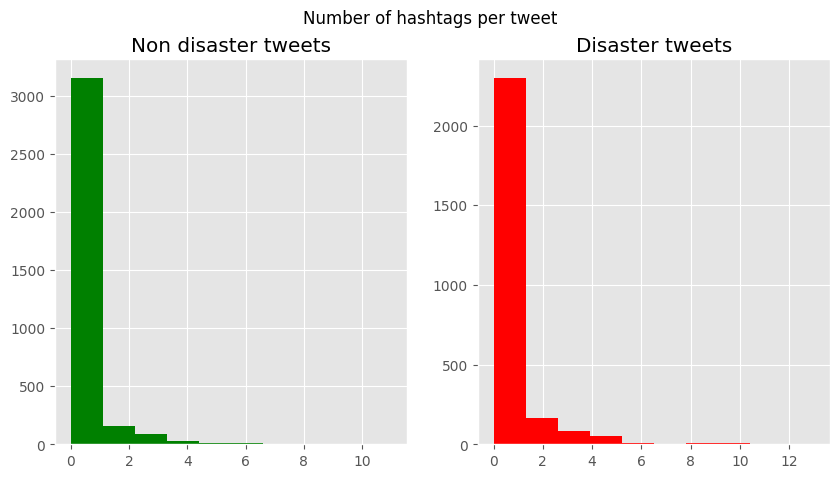

In [12]:
# Counts hashtags; disaster tweets tend to use more hashtags.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

tweet_len_0 = X_train[X_train['target'] == 0]['text'].str.split().map(lambda x: len([w for w in x if w.startswith('#')]))
tweet_len_1 = X_train[X_train['target'] == 1]['text'].str.split().map(lambda x: len([w for w in x if w.startswith('#')]))

ax1.hist(tweet_len_0, color='green')
ax1.set_title('Non disaster tweets')

ax2.hist(tweet_len_1, color='red')
ax2.set_title('Disaster tweets')

fig.suptitle('Number of hashtags per tweet')

plt.show()

### Number of @'s per tweet

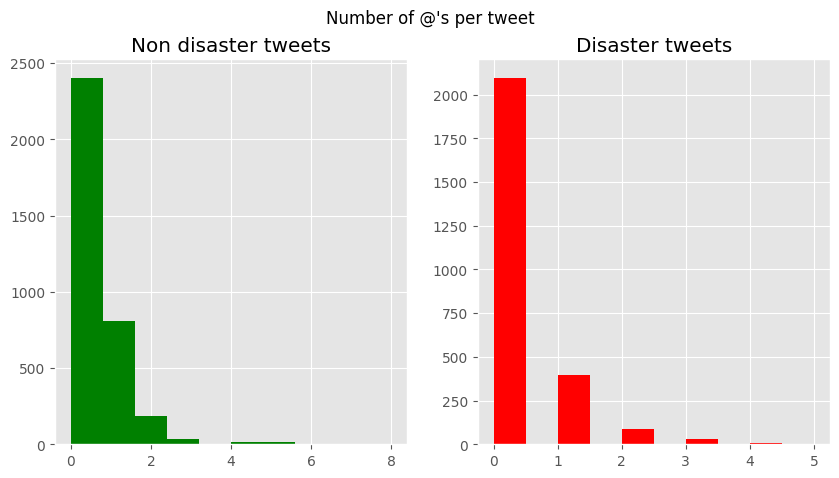

In [13]:
# Counts how many mentios have. Real disastes represent mention real entities  with @
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

tweet_len_0 = X_train[X_train['target'] == 0]['text'].str.split().map(lambda x: len([w for w in x if w.startswith('@')]))
tweet_len_1 = X_train[X_train['target'] == 1]['text'].str.split().map(lambda x: len([w for w in x if w.startswith('@')]))

ax1.hist(tweet_len_0, color='green')
ax1.set_title('Non disaster tweets')

ax2.hist(tweet_len_1, color='red')
ax2.set_title('Disaster tweets')

fig.suptitle("Number of @'s per tweet")

plt.show()

### Number of stop words per tweet

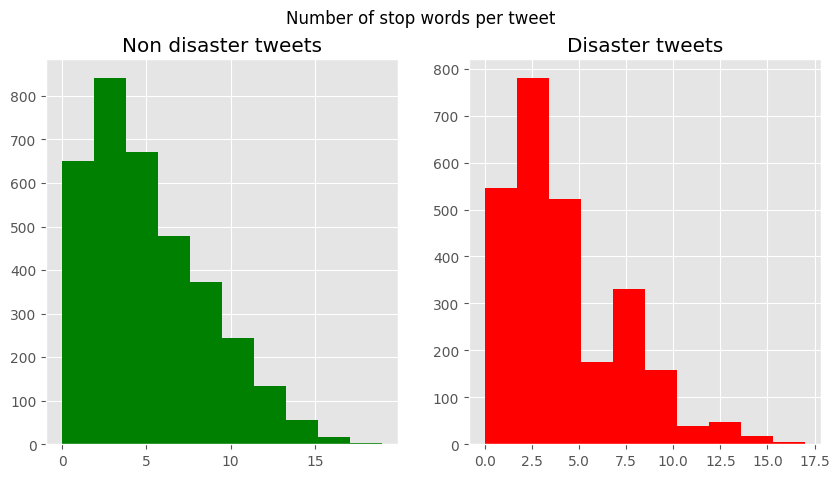

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

stop_words = set(stopwords.words('english'))

tweet_len_0 = X_train[X_train['target'] == 0]['text'].str.split().map(lambda x: len([w for w in x if w.lower() in stop_words]))
tweet_len_1 = X_train[X_train['target'] == 1]['text'].str.split().map(lambda x: len([w for w in x if w.lower() in stop_words]))

ax1.hist(tweet_len_0, color='green')
ax1.set_title('Non disaster tweets')

ax2.hist(tweet_len_1, color='red')
ax2.set_title('Disaster tweets')

fig.suptitle('Number of stop words per tweet')

plt.show()

# 2. Text Cleaning and Technique Comparison

## Create the visualizer functions

In [15]:
# Call stopwords only for english language
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [16]:
def plot_top_stopwords(label):
    tweets_stopwords = {}
    for words in X_train[X_train['target'] == label]['text'].str.split():
        sw = list(set(words).intersection(stopwords.words('english')))
        for w in sw:
            if w in tweets_stopwords.keys():
                tweets_stopwords[w] += 1
            else:
                tweets_stopwords[w] = 1

    top = sorted(tweets_stopwords.items(), key=lambda x:x[1],reverse=True)[:10]
    plt.bar(*zip(*top))
    plt.show()

In [17]:
def plot_top_urls(label):
    tweets_urls = {}
    for words in X_train[X_train['target'] == label]['text'].str.split():
        urls = [w for w in words if w.startswith('http')]
        for w in urls:
            if w in tweets_urls.keys():
                tweets_urls[w] += 1
            else:
                tweets_urls[w] = 1

    top = sorted(tweets_urls.items(), key=lambda x:x[1],reverse=True)[:10]
    plt.bar(*zip(*top))
    plt.xticks(rotation=45)
    plt.show()

In [18]:
def plot_top_mentions(label):
    tweets_mentions = {}
    for words in X_train[X_train['target'] == label]['text'].str.split():
        mentions = [w for w in words if w.startswith('@')]
        for w in mentions:
            if w in tweets_mentions.keys():
                tweets_mentions[w] += 1
            else:
                tweets_mentions[w] = 1

    top = sorted(tweets_mentions.items(), key=lambda x:x[1],reverse=True)[:10]
    plt.bar(*zip(*top))
    plt.xticks(rotation=45)
    plt.show()

## Top NGRAM Analysis

In [19]:
cv = CountVectorizer(ngram_range=(2, 2))  # Count bigrams
sum_words = cv.fit_transform(X_train['text']).sum(axis=0)  # Fit and sum occurrences of each bigram across all tweets

# We calculate the frequency of each bigram and sort by most common
words_freq = [(word, sum_words[0, idx]) for word, idx in cv.vocabulary_.items()]  # Create list
words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)[:20]  # Sort by frequency and keep top 20

## Data set cleaning

In [20]:
# Cleaning functions
import re # to define regular expressions
def to_lowercase(text):
    return text.lower()

def remove_urls(text):
    return re.sub(r'http\S+|www\S+', '', text)

def remove_mentions(text):
    return re.sub(r'@\w+', '', text)

def remove_punctuation(text):
    return re.sub(r'[!"#$%&\'()*+,-./:;<=>?@\[\]^_`{|}~]', '', text)

#### CONFIGURATION 1

In [21]:
def config1(text_in):
    text_out = to_lowercase(text_in)
    text_out = remove_urls(text_out)
    text_out = remove_mentions(text_out)
    text_out = remove_punctuation(text_out)
    return text_out

#### CONFIGURATION 2

In [22]:
def config2(text_in):
    text_out = config1(text_in)
    text_out = ' '.join([w for w in text_out.split() if w not in stopwords.words('english')])
    return text_out

#### CONFIGURATION 3

In [23]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

def config3(text_in):
    text_out = config1(text_in)
    text_out = ' '.join([stemmer.stem(w) for w in text_out.split()])
    return text_out

In [24]:
X_config1 = X_train['text'].apply(config1)
X_config2 = X_train['text'].apply(config2)
X_config3 = X_train['text'].apply(config3)

X_val_config1 = X_val['text'].apply(config1)
X_val_config2 = X_val['text'].apply(config2)
X_val_config3 = X_val['text'].apply(config3)

# 3. Neural Network Impremetation

## Text Vectorization 1

In [25]:
vectorizer1_tv1 = TfidfVectorizer()
X_train_vec1_tv1 = vectorizer1_tv1.fit_transform(X_config1).toarray()
X_val_vec1_tv1 = vectorizer1_tv1.transform(X_val_config1).toarray()

vectorizer2_tv1 = TfidfVectorizer()
X_train_vec2_tv1 = vectorizer2_tv1.fit_transform(X_config2).toarray()
X_val_vec2_tv1 = vectorizer2_tv1.transform(X_val_config2).toarray()

vectorizer3_tv1 = TfidfVectorizer()
X_train_vec3_tv1 = vectorizer3_tv1.fit_transform(X_config3).toarray()
X_val_vec3_tv1 = vectorizer3_tv1.transform(X_val_config3).toarray()

## Model Definition 1

In [60]:
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers

# Use Dropout -> Randomly disable (0.3) 30% of neurons to prevent overfitting

# Config 1
model1 = models.Sequential()
model1.add(layers.Dense(256, activation='relu', input_shape=(X_train_vec1_tv1.shape[1],)))
model1.add(layers.Dropout(0.3))
model1.add(layers.Dense(128, activation='relu'))
model1.add(layers.Dropout(0.3))
model1.add(layers.Dense(64, activation='relu'))
model1.add(layers.Dense(1, activation='sigmoid'))

# Config 2
model2 = models.Sequential()
model2.add(layers.Dense(256, activation='relu', input_shape=(X_train_vec2_tv1.shape[1],)))
model2.add(layers.Dropout(0.3))
model2.add(layers.Dense(128, activation='relu'))
model2.add(layers.Dropout(0.3))
model2.add(layers.Dense(64, activation='relu'))
model2.add(layers.Dense(1, activation='sigmoid'))

# Config 3
model3 = models.Sequential()
model3.add(layers.Dense(256, activation='relu', input_shape=(X_train_vec3_tv1.shape[1],)))
model3.add(layers.Dropout(0.3))
model3.add(layers.Dense(128, activation='relu'))
model3.add(layers.Dropout(0.3))
model3.add(layers.Dense(64, activation='relu'))
model3.add(layers.Dense(1, activation='sigmoid'))


## Text Vectorization 2

In [26]:
vectorizer1_tv2 = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_vec1_tv2 = vectorizer1_tv2.fit_transform(X_config1).toarray()
X_val_vec1_tv2 = vectorizer1_tv2.transform(X_val_config1).toarray()

vectorizer2_tv2 = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_vec2_tv2 = vectorizer2_tv2.fit_transform(X_config2).toarray()
X_val_vec2_tv2 = vectorizer2_tv2.transform(X_val_config2).toarray()

vectorizer3_tv2 = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_vec3_tv2 = vectorizer3_tv2.fit_transform(X_config3).toarray()
X_val_vec3_tv2 = vectorizer3_tv2.transform(X_val_config3).toarray()

## Model Definition 2

In [28]:
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers

# Config 1
model1 = models.Sequential()
model1.add(layers.Dense(256, activation='relu', input_shape=(X_train_vec1_tv2.shape[1],)))
model1.add(layers.Dropout(0.3))
model1.add(layers.Dense(128, activation='relu'))
model1.add(layers.Dropout(0.3))
model1.add(layers.Dense(64, activation='relu'))
model1.add(layers.Dense(1, activation='sigmoid'))

# Config 2
model2 = models.Sequential()
model2.add(layers.Dense(256, activation='relu', input_shape=(X_train_vec2_tv2.shape[1],)))
model2.add(layers.Dropout(0.3))
model2.add(layers.Dense(128, activation='relu'))
model2.add(layers.Dropout(0.3))
model2.add(layers.Dense(64, activation='relu'))
model2.add(layers.Dense(1, activation='sigmoid'))

# Config 3
model3 = models.Sequential()
model3.add(layers.Dense(256, activation='relu', input_shape=(X_train_vec3_tv2.shape[1],)))
model3.add(layers.Dropout(0.3))
model3.add(layers.Dense(128, activation='relu'))
model3.add(layers.Dropout(0.3))
model3.add(layers.Dense(64, activation='relu'))
model3.add(layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Model Compile

In [29]:
# Config 1
model1.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision']
)

# Config 2
model2.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision']
)

# Config 3
model3.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision']
)

## Models Fit V1

In [63]:
history1 = model1.fit(
    X_train_vec1_tv1,
    y_train,
    epochs=40,
    batch_size=16,
    validation_data=(X_val_vec1_tv1, y_val))

model1.save_weights('TV1_model1.weights.h5')

Epoch 1/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - Precision: 0.5031 - accuracy: 0.5633 - loss: 0.6841 - val_Precision: 0.9725 - val_accuracy: 0.7091 - val_loss: 0.6050
Epoch 2/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - Precision: 0.9183 - accuracy: 0.7940 - loss: 0.5094 - val_Precision: 0.7820 - val_accuracy: 0.7997 - val_loss: 0.4668
Epoch 3/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - Precision: 0.9195 - accuracy: 0.9003 - loss: 0.2804 - val_Precision: 0.7639 - val_accuracy: 0.7925 - val_loss: 0.5056
Epoch 4/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - Precision: 0.9494 - accuracy: 0.9438 - loss: 0.1600 - val_Precision: 0.7562 - val_accuracy: 0.7905 - val_loss: 0.5643
Epoch 5/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - Precision: 0.9706 - accuracy: 0.9683 - loss: 0.1018 - val_Precision: 0.7708 - val_accuracy: 0.7879 - val_loss: 0.6253
Epoch 6/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - Precision: 0.9806 - accuracy: 0.9785 - loss: 0.0729 - val_Precision: 0.736

In [64]:
history2 = model2.fit(
    X_train_vec2_tv1,
    y_train,
    epochs=40,
    batch_size=16,
    validation_data=(X_val_vec2_tv1, y_val))

model2.save_weights('TV1_model2.weights.h5')

Epoch 1/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - Precision: 0.4528 - accuracy: 0.5629 - loss: 0.6879 - val_Precision: 1.0000 - val_accuracy: 0.6067 - val_loss: 0.6441
Epoch 2/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - Precision: 0.9530 - accuracy: 0.7287 - loss: 0.5647 - val_Precision: 0.7892 - val_accuracy: 0.7919 - val_loss: 0.4638
Epoch 3/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - Precision: 0.9206 - accuracy: 0.9046 - loss: 0.2736 - val_Precision: 0.7437 - val_accuracy: 0.7774 - val_loss: 0.5096
Epoch 4/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - Precision: 0.9524 - accuracy: 0.9467 - loss: 0.1645 - val_Precision: 0.7317 - val_accuracy: 0.7735 - val_loss: 0.5788
Epoch 5/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - Precision: 0.9682 - accuracy: 0.9673 - loss: 0.1063 - val_Precision: 0.7295 - val_accuracy: 0.7689 - val_loss: 0.6449
Epoch 6/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - Precision: 0.9753 - accuracy: 0.9749 - loss: 0.0747 - val_Precision: 0.741

In [65]:
history3 = model3.fit(
    X_train_vec3_tv1,
    y_train,
    epochs=40,
    batch_size=16,
    validation_data=(X_val_vec3_tv1, y_val))

model3.save_weights('TV1_model3.weights.h5')

Epoch 1/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - Precision: 0.0654 - accuracy: 0.5713 - loss: 0.6838 - val_Precision: 1.0000 - val_accuracy: 0.6356 - val_loss: 0.6149
Epoch 2/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - Precision: 0.9417 - accuracy: 0.7375 - loss: 0.5457 - val_Precision: 0.7549 - val_accuracy: 0.7938 - val_loss: 0.4712
Epoch 3/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - Precision: 0.8935 - accuracy: 0.8821 - loss: 0.3076 - val_Precision: 0.7849 - val_accuracy: 0.8017 - val_loss: 0.4882
Epoch 4/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - Precision: 0.9419 - accuracy: 0.9306 - loss: 0.2022 - val_Precision: 0.7563 - val_accuracy: 0.7879 - val_loss: 0.5424
Epoch 5/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - Precision: 0.9552 - accuracy: 0.9539 - loss: 0.1339 - val_Precision: 0.7372 - val_accuracy: 0.7800 - val_loss: 0.6164
Epoch 6/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - Precision: 0.9684 - accuracy: 0.9699 - loss: 0.0968 - val_Precision: 0.756

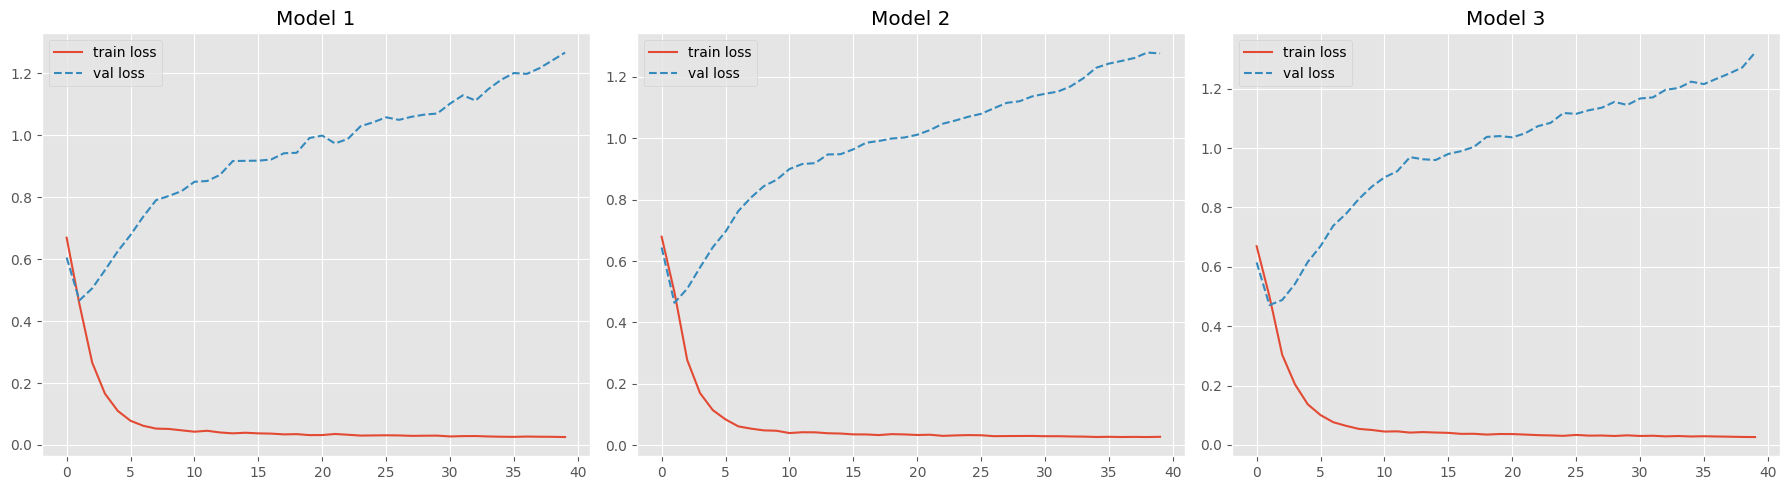

In [66]:
histories = [history1, history2, history3]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (ax, hist) in enumerate(zip(axes, histories), start=1):
    ax.plot(hist.history['loss'], label='train loss')
    ax.plot(hist.history['val_loss'], label='val loss', linestyle='--')
    ax.set_title(f'Model {i}')
    ax.legend()

plt.tight_layout()
plt.show()

## Models Fit V2

In [30]:
history1 = model1.fit(
    X_train_vec1_tv2,
    y_train,
    epochs=40,
    batch_size=16,
    validation_data=(X_val_vec1_tv2, y_val))

model1.save_weights('TV2_model1.weights.h5')

Epoch 1/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - Precision: 0.4377 - accuracy: 0.5394 - loss: 0.6876 - val_Precision: 1.0000 - val_accuracy: 0.6330 - val_loss: 0.6355
Epoch 2/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - Precision: 0.9198 - accuracy: 0.7298 - loss: 0.5641 - val_Precision: 0.8090 - val_accuracy: 0.7991 - val_loss: 0.4591
Epoch 3/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - Precision: 0.8778 - accuracy: 0.8562 - loss: 0.3466 - val_Precision: 0.7986 - val_accuracy: 0.7997 - val_loss: 0.4620
Epoch 4/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - Precision: 0.9113 - accuracy: 0.9004 - loss: 0.2690 - val_Precision: 0.7481 - val_accuracy: 0.7886 - val_loss: 0.4968
Epoch 5/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - Precision: 0.9307 - accuracy: 0.9211 - loss: 0.2090 - val_Precision: 0.7325 - val_accuracy: 0.7794 - val_loss: 0.5368
Epoch 6/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - Precision: 0.9516 - accuracy: 0.9455 - loss: 0.1621 - val_Precision: 0.7476 - v

In [31]:
history2 = model2.fit(
    X_train_vec2_tv2,
    y_train,
    epochs=40,
    batch_size=16,
    validation_data=(X_val_vec2_tv2, y_val))

model2.save_weights('TV2_model2.weights.h5')

Epoch 1/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - Precision: 0.4011 - accuracy: 0.5390 - loss: 0.6886 - val_Precision: 1.0000 - val_accuracy: 0.5817 - val_loss: 0.6546
Epoch 2/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - Precision: 0.9402 - accuracy: 0.6625 - loss: 0.6056 - val_Precision: 0.8122 - val_accuracy: 0.8030 - val_loss: 0.4692
Epoch 3/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - Precision: 0.8793 - accuracy: 0.8585 - loss: 0.3623 - val_Precision: 0.8024 - val_accuracy: 0.8030 - val_loss: 0.4646
Epoch 4/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - Precision: 0.9122 - accuracy: 0.8930 - loss: 0.2757 - val_Precision: 0.7627 - val_accuracy: 0.7905 - val_loss: 0.4937
Epoch 5/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - Precision: 0.9339 - accuracy: 0.9191 - loss: 0.2247 - val_Precision: 0.7317 - val_accuracy: 0.7735 - val_loss: 0.5355
Epoch 6/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - Precision: 0.9441 - accuracy: 0.9373 - loss: 0.1743 - val_Precision: 0.7329 - va

In [32]:
history3 = model3.fit(
    X_train_vec3_tv2,
    y_train,
    epochs=40,
    batch_size=16,
    validation_data=(X_val_vec3_tv2, y_val))

model3.save_weights('TV2_model3.weights.h5')

Epoch 1/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - Precision: 0.4169 - accuracy: 0.5713 - loss: 0.6836 - val_Precision: 1.0000 - val_accuracy: 0.6323 - val_loss: 0.6195
Epoch 2/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - Precision: 0.9235 - accuracy: 0.7335 - loss: 0.5516 - val_Precision: 0.7837 - val_accuracy: 0.7978 - val_loss: 0.4685
Epoch 3/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - Precision: 0.8691 - accuracy: 0.8651 - loss: 0.3425 - val_Precision: 0.7946 - val_accuracy: 0.8037 - val_loss: 0.4708
Epoch 4/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - Precision: 0.9186 - accuracy: 0.9077 - loss: 0.2545 - val_Precision: 0.7979 - val_accuracy: 0.8024 - val_loss: 0.4968
Epoch 5/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - Precision: 0.9376 - accuracy: 0.9321 - loss: 0.2000 - val_Precision: 0.7581 - val_accuracy: 0.7925 - val_loss: 0.5344
Epoch 6/40
381/381 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - Precision: 0.9525 - accuracy: 0.9491 - loss: 0.1586 - val_Precision: 0.7682 - v

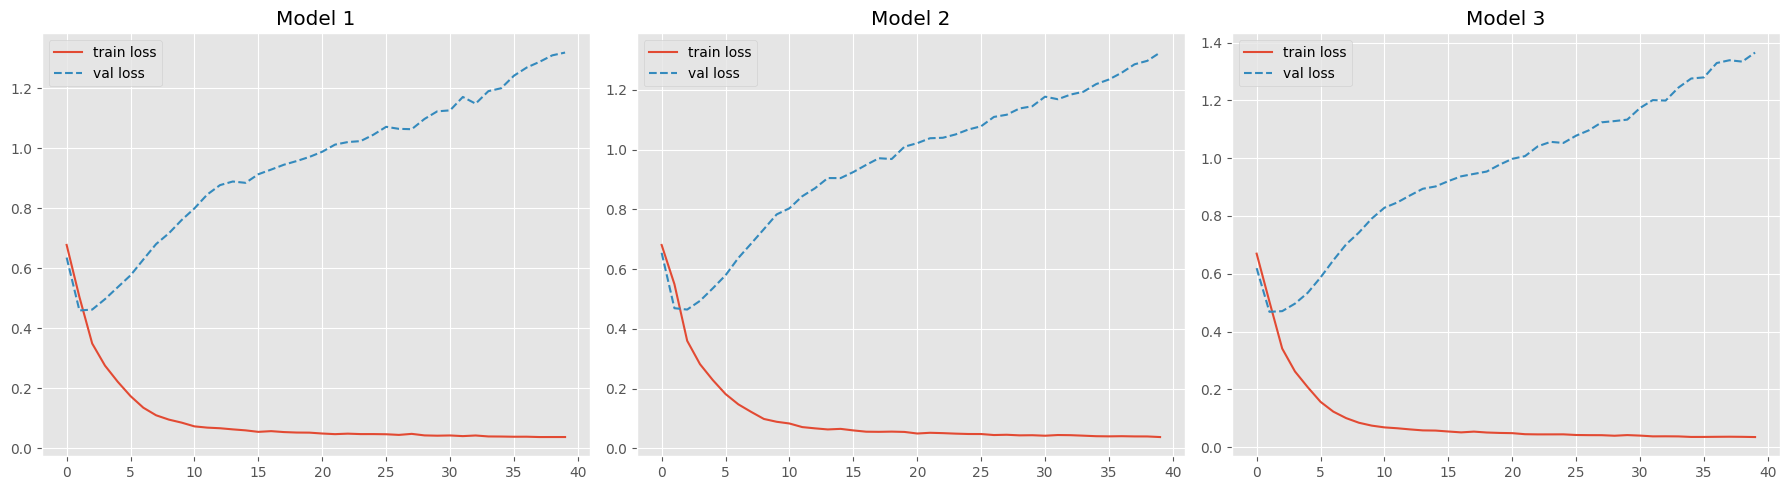

In [34]:
histories2 = [history1, history2, history3]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (ax, hist) in enumerate(zip(axes, histories2), start=1):
    ax.plot(hist.history['loss'], label='train loss')
    ax.plot(hist.history['val_loss'], label='val loss', linestyle='--')
    ax.set_title(f'Model {i}')
    ax.legend()

plt.tight_layout()
plt.show()

## Models Metrics V1


In [69]:
from sklearn.metrics import accuracy_score, f1_score

models_list = [model1, model2, model3]
vecs_list = [X_val_vec1_tv1, X_val_vec2_tv1, X_val_vec3_tv1]

for i in range(3):
    model = models_list[i]
    X_val_vec = vecs_list[i]
    y_pred = (model.predict(X_val_vec) > 0.5).astype(int)  # Convert probabilities to binary classes (0 or 1)

    print(f'=== Model {i} ===')
    print(f'- Accuracy: {accuracy_score(y_val, y_pred):.4f}')
    print(f'- F1: {f1_score(y_val, y_pred):.4f}')
    print("____________________________________")

48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step
=== Model 0 ===
- Accuracy: 0.7544
- F1: 0.7074
____________________________________
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step
=== Model 1 ===
- Accuracy: 0.7360
- F1: 0.6922
____________________________________
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step
=== Model 2 ===
- Accuracy: 0.7571
- F1: 0.6997
____________________________________


### Confusion Matrix

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


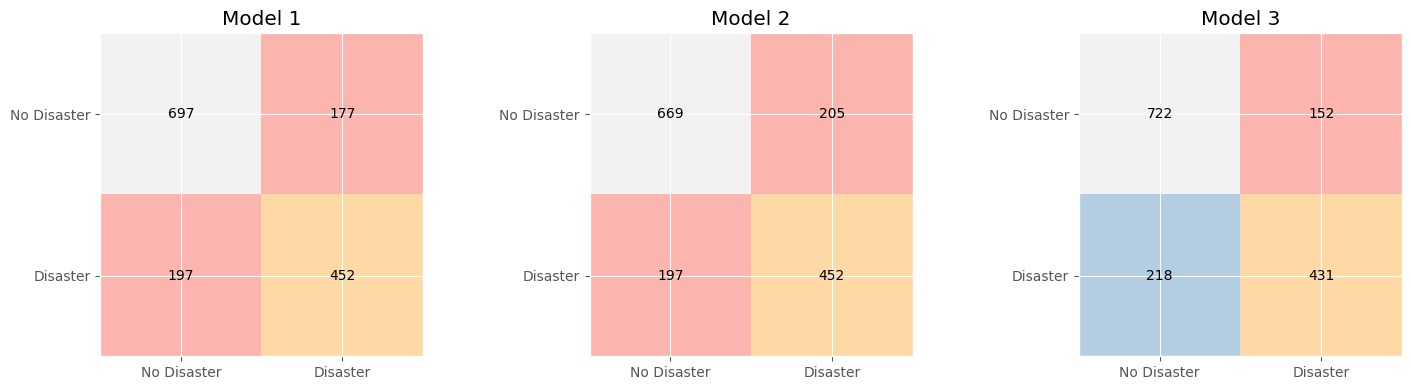

In [71]:
from sklearn.metrics import confusion_matrix

weights_tv1 = ['TV1_model1.weights.h5', 'TV1_model2.weights.h5', 'TV1_model3.weights.h5']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i in range(3):
    models_list[i].load_weights(weights_tv1[i])
    y_pred = (models_list[i].predict(vecs_list[i]) > 0.5).astype(int)
    cm = confusion_matrix(y_val, y_pred)

    axes[i].imshow(cm, cmap='Pastel1')
    axes[i].set_title(f'Model {i+1}')
    axes[i].set_xticks([0, 1])
    axes[i].set_yticks([0, 1])
    axes[i].set_xticklabels(['No Disaster', 'Disaster'])
    axes[i].set_yticklabels(['No Disaster', 'Disaster'])

    for x in range(2):
        for y in range(2):
            axes[i].text(y, x, cm[x, y], ha='center', va='center')

plt.tight_layout()
plt.show()

## Models Metrics V2

In [35]:
from sklearn.metrics import accuracy_score, f1_score

models_list = [model1, model2, model3]
vecs_list = [X_val_vec1_tv2, X_val_vec2_tv2, X_val_vec3_tv2]

for i in range(3):
    model = models_list[i]
    X_val_vec = vecs_list[i]
    y_pred = (model.predict(X_val_vec) > 0.5).astype(int)  # Convert probabilities to binary classes (0 or 1)

    print(f'=== Model {i} ===')
    print(f'- Accuracy: {accuracy_score(y_val, y_pred):.4f}')
    print(f'- F1: {f1_score(y_val, y_pred):.4f}')
    print("____________________________________")

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
=== Model 0 ===
- Accuracy: 0.7735
- F1: 0.7298
____________________________________
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
=== Model 1 ===
- Accuracy: 0.7466
- F1: 0.7035
____________________________________
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
=== Model 2 ===
- Accuracy: 0.7623
- F1: 0.7154
____________________________________


48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


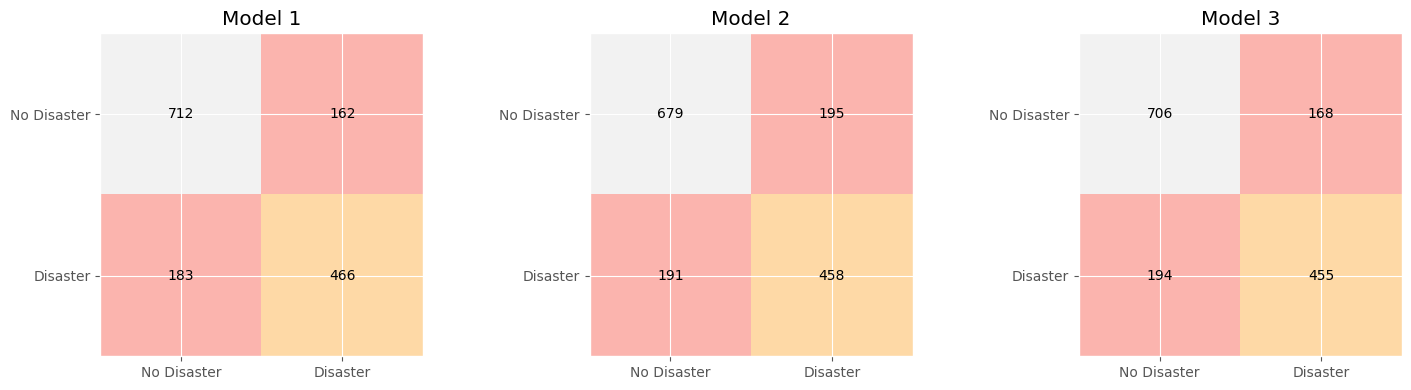

In [36]:
from sklearn.metrics import confusion_matrix

weights_tv2 = ['TV2_model1.weights.h5', 'TV2_model2.weights.h5', 'TV2_model3.weights.h5']
vecs_list = [X_val_vec1_tv2, X_val_vec2_tv2, X_val_vec3_tv2]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i in range(3):
    models_list[i].load_weights(weights_tv2[i])
    y_pred = (models_list[i].predict(vecs_list[i]) > 0.5).astype(int)
    cm = confusion_matrix(y_val, y_pred)

    axes[i].imshow(cm, cmap='Pastel1')
    axes[i].set_title(f'Model {i+1}')
    axes[i].set_xticks([0, 1])
    axes[i].set_yticks([0, 1])
    axes[i].set_xticklabels(['No Disaster', 'Disaster'])
    axes[i].set_yticklabels(['No Disaster', 'Disaster'])

    for x in range(2):
        for y in range(2):
            axes[i].text(y, x, cm[x, y], ha='center', va='center')

plt.tight_layout()
plt.show()

# 4. Neural Network Comparations (CODE)

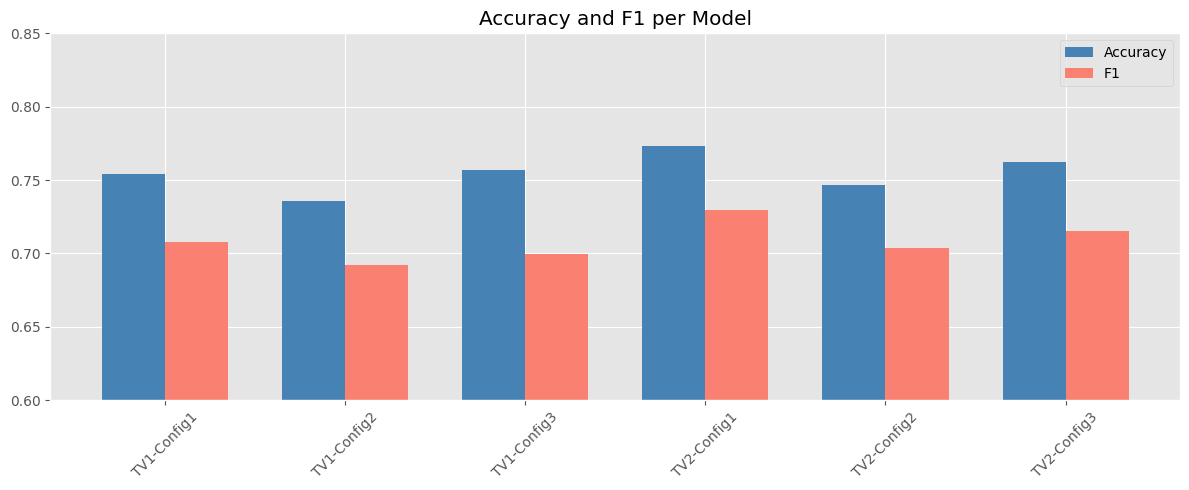

In [37]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['TV1-Config1', 'TV1-Config2', 'TV1-Config3', 'TV2-Config1', 'TV2-Config2', 'TV2-Config3']
accuracy = [0.7544, 0.7360, 0.7571, 0.7735, 0.7466, 0.7623]
f1 = [0.7074, 0.6922, 0.6997, 0.7298, 0.7035, 0.7154]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, accuracy, width, label='Accuracy', color='steelblue')
ax.bar(x + width/2, f1, width, label='F1', color='salmon')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.set_ylim(0.6, 0.85)
ax.legend()
ax.set_title('Accuracy and F1 per Model')

plt.tight_layout()
plt.show()

# 5. Comparative Table and Analysis (answers of the section 2)

| Preprocessing | Stopwords | Stemming | Vectorization | Accuracy | F1 |
|---|---|---|---|---|---|
| Config 1 | Yes | No | TV1 | 0.7544 | 0.7074 |
| Config 2 | No | No | TV1 | 0.7360 | 0.6922 |
| Config 3 | Yes | Yes | TV1 | 0.7571 | 0.6997 |
| Config 1 | Yes | No | TV2 | 0.7735 | 0.7298 |
| Config 2 | No | No | TV2 | 0.7466 | 0.7035 |
| Config 3 | Yes | Yes | TV2 | 0.7623 | 0.7154 |

### Analysis
**What happens when stopwords are removed? (Config 2)**

When we remove stopwords, the model actually performs worse in both cases (TV1: 0.7360, TV2: 0.7466).
This makes sense because words like "no", "not" or "but" can change the meaning of a tweet completely,
so removing them makes it harder for the model to understand what is really  say the tweet.

**What happens when stopwords are kept? (Config 1)**

Keeping stopwords gives the best results overall (TV1: 0.7544, TV2: 0.7735).
The model works better when the tweets keep their natural structure,
since the full sentence gives more context to decide if something is a disaster or not.

**What is the impact of stemming? (Config 3)**

Stemming shows mixed results. In TV1 accuracy goes up a little (0.7571 vs 0.7544) but F1 goes down (0.6997 vs 0.7074).
In TV2 both metrics are lower than Config 1. This means that reducing words to their root form
can sometimes remove details that the model needs to classify tweets correctly.

# 6. Real-Time Prediction

In [31]:
import pickle
from tensorflow.keras import models, layers

pickle.dump(vectorizer3_tv1, open('vectorizer3_tv1.pkl', 'wb'))
pickle.dump(vectorizer1_tv2, open('vectorizer1_tv2.pkl', 'wb'))

def build_model(input_shape, weights):
    model = models.Sequential([
        layers.Dense(256, activation='relu', input_shape=(input_shape,)),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.load_weights(weights)
    return model

def prediction_final(sentence):
    vec_tv1 = pickle.load(open('vectorizer3_tv1.pkl', 'rb'))
    tweet_vec = vec_tv1.transform([config3(sentence)]).toarray()
    confidence = build_model(tweet_vec.shape[1], 'TV1_model3.weights.h5').predict(tweet_vec)[0][0]
    print(f'=== TV1 - Best Model (Config 3) ===')
    print(f'Prediction: {"Disaster" if confidence > 0.5 else "No Disaster"}')
    print(f'Confidence: {confidence:.2f}\n')

    vec_tv2 = pickle.load(open('vectorizer1_tv2.pkl', 'rb'))
    tweet_vec = vec_tv2.transform([config1(sentence)]).toarray()
    confidence = build_model(5000, 'TV2_model1.weights.h5').predict(tweet_vec)[0][0]
    print(f'=== TV2 - Best Model (Config 1) ===')
    print(f'Prediction: {"Disaster" if confidence > 0.5 else "No Disaster"}')
    print(f'Confidence: {confidence:.2f}')

tweet = input('Enter a tweet: ')
prediction_final(tweet)

Enter a tweet: disaster


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


=== TV1 - Best Model (Config 3) ===
Prediction: No Disaster
Confidence: 0.35

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
=== TV2 - Best Model (Config 1) ===
Prediction: Disaster
Confidence: 0.82
